<a href="https://colab.research.google.com/github/KARISHMA674/microscopy-3d-visualizer/blob/main/ImageAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image analysis

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from skimage import exposure, io, util
from skimage.data import cells3d
#load and display 3d
data=util.img_as_float(cells3d()[:,1,:,:]) #nuclie data
print(data)


[[[0.08104067 0.06802472 0.08972305 ... 0.06439307 0.09913787 0.0752575 ]
  [0.06222629 0.06945907 0.05427634 ... 0.06945907 0.07452506 0.07887388]
  [0.0520943  0.07742428 0.06657511 ... 0.06222629 0.09333944 0.08249027]
  ...
  [0.06077668 0.06077668 0.04196231 ... 0.06729229 0.0701915  0.08972305]
  [0.05499351 0.0636759  0.0701915  ... 0.08465705 0.08682383 0.06512551]
  [0.06222629 0.06512551 0.06439307 ... 0.0817731  0.10202182 0.11432059]]

 [[0.06439307 0.0752575  0.07742428 ... 0.09840543 0.09333944 0.0752575 ]
  [0.04702831 0.07597467 0.06874189 ... 0.06874189 0.10637064 0.08972305]
  [0.07164111 0.06584268 0.07164111 ... 0.07235828 0.08827344 0.07742428]
  ...
  [0.0520943  0.0586099  0.05282673 ... 0.07887388 0.07235828 0.0767071 ]
  [0.0636759  0.05064469 0.04269474 ... 0.08249027 0.0701915  0.07380789]
  [0.04921035 0.05427634 0.05571069 ... 0.08320745 0.08249027 0.07380789]]

 [[0.06945907 0.06874189 0.07235828 ... 0.06802472 0.07597467 0.07090867]
  [0.05137713 0.065125

In [7]:
data.shape

(60, 256, 256)

In [8]:
data.dtype

dtype('float64')

In [10]:
data.min()

np.float64(0.0)

In [11]:
data.max()

np.float64(1.0)

#report spacing from microschape

In [12]:
original_spacing=np.array([0.2900,0.0650,0.0650])
print(original_spacing)

[0.29  0.065 0.065]


In [13]:
resculed_spacing=original_spacing*[1,4,4]
print(resculed_spacing)

[0.29 0.26 0.26]


In [14]:
spacing=resculed_spacing/resculed_spacing[1]
print(spacing)

[1.11538462 1.         1.        ]


In [18]:
spacing=resculed_spacing/resculed_spacing[2]
print(spacing)

[1.11538462 1.         1.        ]


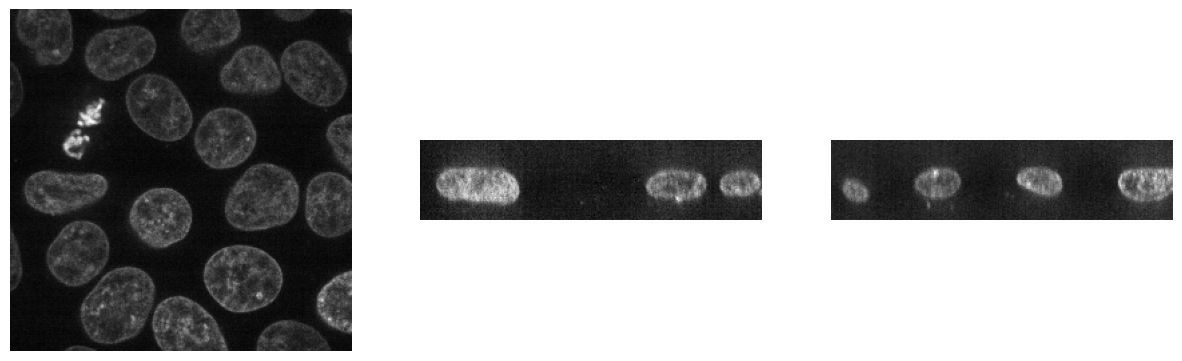

In [22]:
def show_plane(ax,plane,cmap="gray",title=None):
  ax.imshow(plane,cmap=cmap)
  ax.axis("off")
  if title:
    ax.set_title(title)
(n_plane,n_row,n_col)=data.shape
_,(a,b,c)=plt.subplots(ncols=3,figsize=(15,5))
show_plane(a,data[n_plane//2])
show_plane(b,data[:,n_row//2])
show_plane(c,data[:,:,n_col//2])



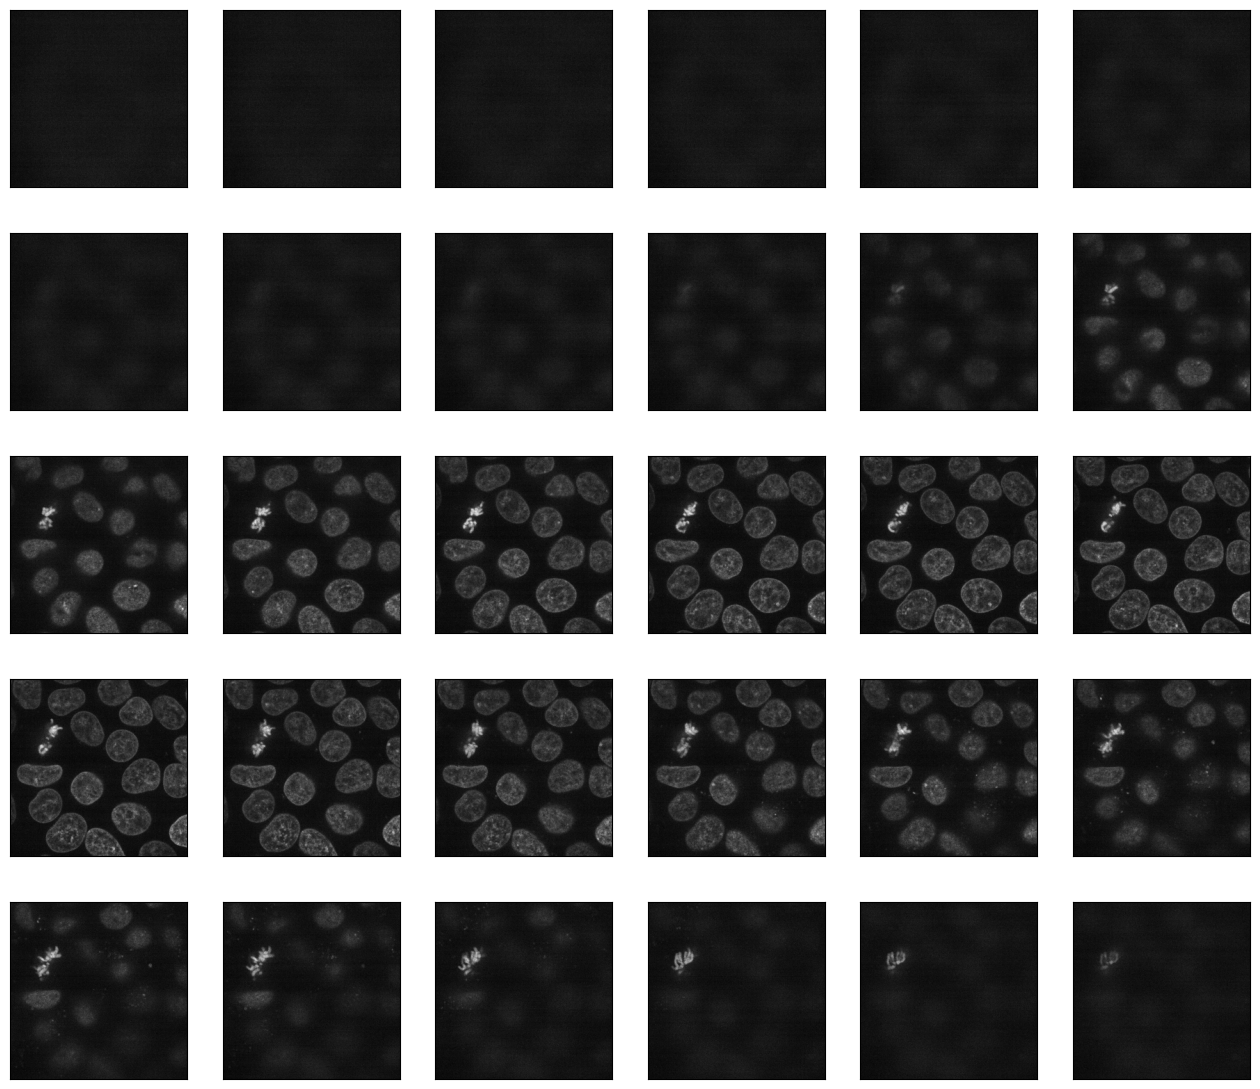

In [24]:
def display(im3d,cmap="gray",step=2):
  fig,axes=plt.subplots(5,6,figsize=(16,14))
  vmin=im3d.min()
  vmax=im3d.max()
  for ax,image in zip(axes.flatten(),im3d[::step]):
    ax.imshow(image,cmap=cmap,vmin=vmin,vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])
display(data)